Before you turn this problem in, make sure everything runs as expected. First, **restart the kernel** (in the menu bar, select Kernel$\rightarrow$Restart) and then **run all cells** (in the menu bar, select Cell$\rightarrow$Run All).

Make sure that in addition to the code, you provide written answers for all questions of the assignment.

Below, please fill in your name:

In [1]:
NAME = "Darrah A. Borinaga"

## Assignment 1 - Data Cleaning & Exploration
**(30 points total)**

For this assignment, we will use an open dataset with data on various types of cereal and the corresponding customer ratings. Use the .csv file provided.

Create a dataframe by importing the file into Jupyter, and complete the tasks below. Be sure to show your Python code. You will not be graded on code efficiency, but your code should return a correct answer.

**Question 1.**  _(4 points)_
* Create a new 'Type of Cereal' column in your dataframe (1 point) by copying the 'name' column. Write a function to replace the names of the cereal in your new column with one of these categories Bran, Wheat, Fiber, Protein, Crunch, Corn, Nut, Rice and Other (3 points). Hint: the function should look through the text in the cereal name and determine, based on its contents, how to categorize the cereal type.

**Question 2.**  _(2 points)_
* Identify the negative values in the data set and replace them with the median value for that column.

**Question 3.** _(5 points)_
* Standardize the 'weight' column to 1. For this question, you will need to write a function to divide the remaining columns which contain nutritional information by the corresponding value in the weight column, and you will need to divide the value in the weight column by itself in order to get 1. For example, if an observation has a weight value of 1.33 and a calories value of 250, if you divide 250/1.33 you should get a calories value of 188 and a weight value of 1.

**Question 4.**  _(5 points)_
* Create a new column to categorize cereals as 'healthy' vs. 'unhealthy'. You can define your own version of healthy vs. unhealthy, or you can use the following: healthy cereals can be defined as those which have low calories (<100), low sodium (<150), low sugar (<9) high fiber (>3), and high protein (>2). All other cereals are unhealthy.

**Question 5.** _(2 points)_
* Based on your newly prepared data set, identify what % of cereals that each manufacturer produces are healthy.

**Question 6.** _(2 points)_
* Calculate the average, minimum and maximum ratings for healthy vs. unhealthy cereals.

**Question 7.** _(2 points)_
* Calculate the average, minimum and maximum ratings for each type of cereal: Bran, Wheat, Fiber, Protein, Crunch, Corn, Nut, Rice and Other.

**Question 8.** _(3 points)_
* Create a stacked bar chart which shows how many of each type of cereal each manufacturer produces.

**Question 9.** _(3 points)_
* Create a 3-dimensional scatterplot which shows the relationship between rating and calories; the 3-rd dimension should be reflected in the color of the dots and should highlight whether the cereal is categorized as healthy or unhealthy.

**Question 10.** _(1 point)_
* Which shelf has the most healthy cereals?

**Question 11.** _(1 point)_
* Based on the analysis conducted, what can you conclude about the cereal data set?

In [1]:
# Name: Darrah Borinaga

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.colab import files

uploaded = files.upload()

Saving cereal-1.csv to cereal-1 (1).csv


In [3]:
import os
print(os.listdir("/content"))

['.config', 'cereal-1 (1).csv', 'cereal-1.csv', 'sample_data']


In [5]:
df = pd.read_csv("/content/cereal-1 (1).csv")
print(df.head())

                        name mfr type  calories  protein  fat  sodium  fiber  \
0                  100% Bran   N    C        70        4    1     130   10.0   
1          100% Natural Bran   Q    C       120        3    5      15    2.0   
2                   All-Bran   K    C        70        4    1     260    9.0   
3  All-Bran with Extra Fiber   K    C        50        4    0     140   14.0   
4             Almond Delight   R    C       110        2    2     200    1.0   

   carbo  sugars  potass  vitamins  shelf  weight  cups     rating  
0    5.0       6     280        25      3     1.0  0.33  68.402973  
1    8.0       8     135         0      3     1.0  1.00  33.983679  
2    7.0       5     320        25      3     1.0  0.33  59.425505  
3    8.0       0     330        25      3     1.0  0.50  93.704912  
4   14.0       8      -1        25      3     1.0  0.75  34.384843  


In [6]:
print(df.shape)

(77, 16)


In [7]:
df["Type of Cereal"] = df["name"]

In [8]:
# Question 1

df["Type of Cereal"] = df["name"]

def cereal_type(name):
    name = name.lower()
    if "bran" in name:
        return "Bran"
    elif "wheat" in name:
        return "Wheat"
    elif "fiber" in name:
        return "Fiber"
    elif "protein" in name:
        return "Protein"
    elif "crunch" in name:
        return "Crunch"
    elif "corn" in name:
        return "Corn"
    elif "nut" in name:
        return "Nut"
    elif "rice" in name:
        return "Rice"
    else:
        return "Other"

df["Type of Cereal"] = df["Type of Cereal"].apply(cereal_type)
df[["name", "Type of Cereal"]].head()

,name,Type of Cereal
0,100% Bran,Bran
1,100% Natural Bran,Bran
2,All-Bran,Bran
3,All-Bran with Extra Fiber,Bran
4,Almond Delight,Other


In [10]:
# Question 2

numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    median_value = df.loc[df[col] >= 0, col].median()
    df.loc[df[col] < 0, col] = median_value

df.describe()

,calories,protein,fat,sodium,fiber,carbo,sugars,potass,vitamins,shelf,weight,cups,rating
count,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000
mean,106.883117,2.545455,1.012987,159.675325,2.151948,14.798701,7.025974,98.441558,28.246753,2.207792,1.029610,0.821039,42.665705
std,19.484119,1.094790,1.006473,83.832295,2.383364,3.881688,4.349755,69.491857,22.342523,0.832524,0.150477,0.232716,14.047289
min,50.000000,1.000000,0.000000,0.000000,0.000000,5.000000,0.000000,15.000000,0.000000,1.000000,0.500000,0.250000,18.042851
25%,100.000000,2.000000,0.000000,130.000000,1.000000,12.000000,3.000000,45.000000,25.000000,1.000000,1.000000,0.670000,33.174094
50%,110.000000,3.000000,1.000000,180.000000,2.000000,14.500000,7.000000,90.000000,25.000000,2.000000,1.000000,0.750000,40.400208
75%,110.000000,3.000000,2.000000,210.000000,3.000000,17.000000,11.000000,120.000000,25.000000,3.000000,1.000000,1.000000,50.828392
max,160.000000,6.000000,5.000000,320.000000,14.000000,23.000000,15.000000,330.000000,100.000000,3.000000,1.500000,1.500000,93.704912


In [11]:
# Question 3

nutrition_cols = [
    "calories", "protein", "fat", "sodium", "fiber",
    "carbo", "sugars", "potass", "vitamins"
]

def standardize_by_weight(row):
    weight = row["weight"]
    for col in nutrition_cols:
        row[col] = row[col] / weight
    row["weight"] = row["weight"] / weight
    return row

df = df.apply(standardize_by_weight, axis=1)
df.head()

,name,mfr,type,calories,protein,fat,sodium,fiber,carbo,sugars,potass,vitamins,shelf,weight,cups,rating
0,100% Bran,N,C,70.0,4.0,1.0,130.0,10.0,5.0,6.0,280.0,25.0,3,1.0,0.33,68.402973
1,100% Natural Bran,Q,C,120.0,3.0,5.0,15.0,2.0,8.0,8.0,135.0,0.0,3,1.0,1.00,33.983679
2,All-Bran,K,C,70.0,4.0,1.0,260.0,9.0,7.0,5.0,320.0,25.0,3,1.0,0.33,59.425505
3,All-Bran with Extra Fiber,K,C,50.0,4.0,0.0,140.0,14.0,8.0,0.0,330.0,25.0,3,1.0,0.50,93.704912
4,Almond Delight,R,C,110.0,2.0,2.0,200.0,1.0,14.0,8.0,90.0,25.0,3,1.0,0.75,34.384843


In [12]:
# Question 4

def healthy_status(row):
    if (
        row["calories"] < 100 and
        row["sodium"] < 150 and
        row["sugars"] < 9 and
        row["fiber"] > 3 and
        row["protein"] > 2
    ):
        return "Healthy"
    else:
        return "Unhealthy"

df["Health Status"] = df.apply(healthy_status, axis=1)
df[["name", "Health Status"]].head()

,name,Health Status
0,100% Bran,Healthy
1,100% Natural Bran,Unhealthy
2,All-Bran,Unhealthy
3,All-Bran with Extra Fiber,Healthy
4,Almond Delight,Unhealthy


In [13]:
# Question 5

healthy_percent = df.groupby("mfr")["Health Status"].apply(
    lambda x: (x == "Healthy").mean() * 100
)

healthy_percent

,Health Status
mfr,
A,0.000000
G,0.000000
K,4.347826
N,50.000000
P,11.111111
Q,0.000000
R,0.000000


In [14]:
# Written answer for Question 5
print("Manufacturer N produces the highest percentage of healthy cereals.")

Manufacturer N produces the highest percentage of healthy cereals.


In [15]:
# Question 6

rating_health = df.groupby("Health Status")["rating"].agg(["mean", "min", "max"])
rating_health

,mean,min,max
Health Status,,,
Healthy,69.146753,40.917047,93.704912
Unhealthy,40.826743,18.042851,72.801787


In [18]:
# Question 7

def cereal_type(name):
    name = name.lower()
    if "bran" in name:
        return "Bran"
    elif "wheat" in name:
        return "Wheat"
    elif "fiber" in name:
        return "Fiber"
    elif "protein" in name:
        return "Protein"
    elif "crunch" in name:
        return "Crunch"
    elif "corn" in name:
        return "Corn"
    elif "nut" in name:
        return "Nut"
    elif "rice" in name:
        return "Rice"
    else:
        return "Other"

df["Type of Cereal"] = df["name"].apply(cereal_type)

df[["name", "Type of Cereal"]].head()

,name,Type of Cereal
0,100% Bran,Bran
1,100% Natural Bran,Bran
2,All-Bran,Bran
3,All-Bran with Extra Fiber,Bran
4,Almond Delight,Other


In [19]:
rating_type = df.groupby("Type of Cereal")["rating"].agg(["mean", "min", "max"])
rating_type

,mean,min,max
Type of Cereal,,,
Bran,50.714179,28.592785,93.704912
Corn,40.482720,35.782791,45.863324
Crunch,26.078598,18.042851,36.523683
Nut,42.433500,31.072217,53.371007
Other,37.281694,21.871292,55.333142
Rice,47.771735,40.560159,60.756112
Wheat,56.333863,36.176196,72.801787


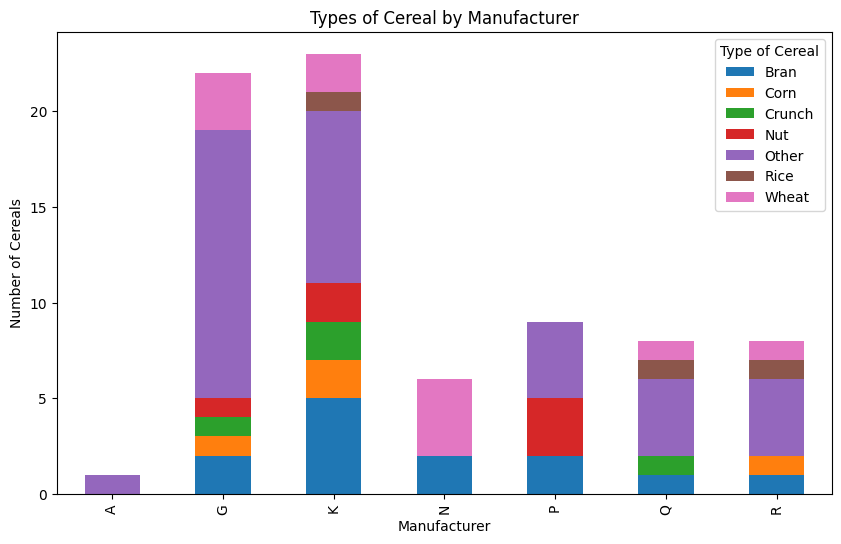

In [20]:
# Question 8

stacked_data = pd.crosstab(df["mfr"], df["Type of Cereal"])

stacked_data.plot(kind="bar", stacked=True, figsize=(10, 6))
plt.title("Types of Cereal by Manufacturer")
plt.xlabel("Manufacturer")
plt.ylabel("Number of Cereals")
plt.legend(title="Type of Cereal")
plt.show()

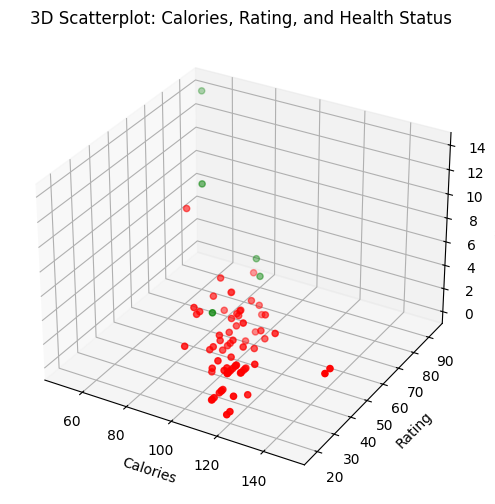

In [21]:
# Question 9

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection="3d")

colors = df["Health Status"].map({"Healthy": "green", "Unhealthy": "red"})

ax.scatter(df["calories"], df["rating"], df["fiber"], c=colors)

ax.set_xlabel("Calories")
ax.set_ylabel("Rating")
ax.set_zlabel("Fiber")
ax.set_title("3D Scatterplot: Calories, Rating, and Health Status")

plt.show()

In [22]:
# Question 10

healthy_cereals = df[df["Health Status"] == "Healthy"]
shelf_counts = healthy_cereals["shelf"].value_counts()

print(shelf_counts)
print("Shelf with the most healthy cereals:", shelf_counts.idxmax())

shelf
3    3
1    2
Name: count, dtype: int64
Shelf with the most healthy cereals: 3


Based on my analysis, I found that the cereal dataset contained a few invalid negative values,
which I cleaned by replacing them with the median values of their respective columns. I also
standardized the nutritional information by adjusting all values based on a weight of 1, making
the data more consistent for comparison.

After cleaning the data, I classified each cereal as either healthy or unhealthy using the given
nutrition criteria. The results showed that healthy cereals generally received higher customer
ratings than unhealthy cereals. I also found that Manufacturer N produced the highest percentage
of healthy cereals, while Shelf 3 contained the largest number of healthy cereal products.

Overall, this analysis demonstrates that proper data cleaning improves the quality of the dataset
and allows for more meaningful insights. It also suggests that cereals with healthier nutritional
profiles tend to receive better customer ratings.